In [ ]:
! pip install wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=37a3b86c9a6179588a28be2c73dcef936a868dd598a18dc07a18eaaa458be7e2
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


In [ ]:
import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd

Using tfidf technique to classify the text based on the topics

In [ ]:
topic1 = 'Sinus'
topic2 = 'Cataract'

wikipedia.set_lang('it')

it1 = wikipedia.page(topic1).content
it2 = wikipedia.page(topic2).content

wikipedia.set_lang('es')

es1 = wikipedia.page(topic1).content
es2 = wikipedia.page(topic2).content

In [ ]:
def clean_doc(doc):
    doc = doc.lower()
    doc = re.sub('[^a-z]', ' ', doc)
    return doc

In [ ]:
cleaned_it1 = clean_doc(it1)
cleaned_it2 = clean_doc(it2)

In [ ]:
print(cleaned_it1)

la focena del golfo di california  phocoena sinus  o vaquita  termine spagnolo che significa  piccola vacca     una rara specie di focena    endemica della parte settentrionale del golfo di california  o mare di cortez   si stima che ne siano rimasti solo    individui    uno dei cetacei pi  piccoli al mondo  se non il pi  piccolo in assoluto        descrizione fisica     la focena del golfo di california presenta la classica forma della focena  robusta e ricurva a forma concava quando viene vista di lato     la pi  piccola delle focene ed   cos  uno dei cetacei pi  piccoli  gli individui raggiungono i     centimetri di lunghezza e i       chilogrammi di peso  hanno un grande anello nero intorno all occhio e delle macchie sul labbro  la regione superiore del corpo va dal grigio medio al grigio scuro  quella inferiore va dal bianco al grigio chiaro  ma la demarcazione sui fianchi   indistinta  le natatoie sono in proporzione pi  grandi che in altre focene e la pinna   pi  bassa e pi  fal

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
corpus_it = [cleaned_it1, cleaned_it2]
vectorizer_it = TfidfVectorizer()
tfidf_matrix_it = vectorizer_it.fit_transform(corpus_it)
feature_names_it = vectorizer_it.get_feature_names_out()
tfidf_df_it = pd.DataFrame(tfidf_matrix_it.toarray(), columns=feature_names_it)
print(tfidf_df_it.round(3))

   abitano  accolta  acqua  acque  acronimo  adducendo  aggressivo   agli  \
0    0.017    0.000  0.052  0.052     0.017      0.000       0.000  0.017   
1    0.000    0.028  0.000  0.000     0.000      0.028       0.028  0.000   

   agosto  agrosa  ...  whales  wikimedia  wikispecies  wiley   with  world  \
0   0.017   0.017  ...   0.017      0.017        0.017  0.017  0.000  0.017   
1   0.000   0.000  ...   0.000      0.000        0.000  0.000  0.056  0.000   

   worms   zero   zink   zona  
0  0.017  0.017  0.000  0.017  
1  0.000  0.000  0.028  0.000  

[2 rows x 691 columns]


In [ ]:
max_tfidf_scores = tfidf_df_it.max()
sorted_columns = max_tfidf_scores.sort_values(ascending=False).index
tfidf_df_sorted = tfidf_df_it[sorted_columns]
display(tfidf_df_sorted.round(3))

,di,cataract,la,che,fu,il,nel,su,band,sinus,...,pescatori,passport,parente,pacific,orlo,online,on,cms,inbreeding,pesticidi
0,0.406,0.000,0.308,0.246,0.000,0.209,0.025,0.148,0.000,0.19,...,0.017,0.017,0.017,0.017,0.017,0.017,0.017,0.017,0.017,0.017
1,0.120,0.394,0.200,0.080,0.225,0.220,0.220,0.200,0.197,0.00,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


Here, the words are desceningly sorted based on the tfidf values, the common words like di(Of), la(there), che(that), fu(it was), il(the), nel(in the), su(on).

By analyzing this, ngrams might be the best way to distinguish italian from other languages, because, the filler words such as there, that, of, the are all bigrams and other compound filler words used in english (in the) 'nel' in italian, (it was) 'fu' in italian are bigrams and trigrams

In [ ]:
cleaned_es1 = clean_doc(es1)
cleaned_es2 = clean_doc(es2)
corpus_es = [cleaned_es1, cleaned_es2]
vectorizer_es = TfidfVectorizer()
tfidf_matrix_es = vectorizer_es.fit_transform(corpus_es)
feature_names_es = vectorizer_es.get_feature_names_out()
tfidf_df_es = pd.DataFrame(tfidf_matrix_es.toarray(), columns=feature_names_es)
print(tfidf_df_es.round(3))

   abandono  abril  acompa  actualmente    ado  agresivo     al  alberga  \
0     0.000  0.000   0.000        0.021  0.000     0.000  0.015    0.021   
1     0.022  0.022   0.022        0.000  0.022     0.022  0.063    0.000   

   alessandro  alineaci  ...  visions   vivo  vocalista    voz  website  \
0       0.000     0.000  ...    0.000  0.000      0.000  0.000    0.000   
1       0.022     0.066  ...    0.022  0.022      0.044  0.044    0.022   

    well   wiki  wikimedia   with     ya  
0  0.000  0.021      0.021  0.000  0.000  
1  0.022  0.000      0.000  0.066  0.022  

[2 rows x 402 columns]


In [ ]:
max_tfidf_scores_es = tfidf_df_es.max()
sorted_columns_es = max_tfidf_scores_es.sort_values(ascending=False).index
tfidf_df_sorted_es = tfidf_df_es[sorted_columns_es]
display(tfidf_df_sorted_es.round(3))

,de,en,el,cataract,la,sinus,banda,cr,lbum,iridum,...,aprobado,arco,uni,hasta,pero,lo,externos,enlaces,quienes,tambi
0,0.607,0.091,0.318,0.000,0.303,0.234,0.000,0.213,0.000,0.192,...,0.021,0.021,0.021,0.015,0.015,0.015,0.015,0.015,0.015,0.015
1,0.330,0.409,0.362,0.309,0.267,0.000,0.221,0.000,0.199,0.000,...,0.000,0.000,0.000,0.016,0.016,0.016,0.016,0.016,0.016,0.016


de -> of
en -> in
el -> he
la -> the
These are all bigrams with highest occurance in text.

So, the best way to classify topics based on text, the best way is to find the difference between the k-top descending words based on tfidf scores and the k-top descendingly ordered bigram distribution words.

Bigrams

In [ ]:
def cleanup(text):
  text = text.lower()  # make it lowercase
  text = re.sub('[^a-z]+', '', text) # only keep characters
  return text

In [ ]:
new_it1 = cleanup(it1)
new_it2 = cleanup(it2)
new_es1 = cleanup(es1)
new_es2 = cleanup(es2)

In [ ]:
new_es1

'sinusiridumbahadelarcoiriseslamsespectacularybellabahadelalunavisibleinclusoconprismticosseencuentraubicadaalnoroestedelmareimbriumsetratadeuncrterdeimpactodekmdedimetroelcualhabraperdidosuparedsuresteformandolabahasuinterioresfundamentalmentellanocompuestodelavabaslticaconnumerososcrteresdemuypequeotamaoascomounaseriedecrestasdorsaprobablementedebidasalacompresindelosflujosdelavadurantelosltimosestadiosdeenfriamientoenelbordeexteriordelcrterseencuentranlosmontesjuraformandounsemianillodeunoskmdelongitudconstituidosporrestosdelamurallainicialestncompuestosporvariaslneasdecumbresparalelasyconcntricasdekmdeanchurapresentandopicosqueseelevanhastamdealtitudenelextremoorientaldelacordilleraseencuentraelpromontoriolaplacedemdealtitudyenelextremooccidentalsesitaelpromontorioheraclidesdemdealtitudenelcentrodelacordilleraseencuentraelcrterbianchinidekmdedimetroyunaprofundidaddemsecreequedespusdequeseformelcrterdesinusiridumunimpactomuchomsgrandeformelcrterdondeactualmenteestelmareimbriumestelt

In [ ]:
# convert a tuple of characters to a string
def tuple2string(tup):
  st = ''
  for ii in tup:
    st = st + ii
  return st

# convert a tuple of tuples to a list of strings
def key2string(keys):
  return [tuple2string(i) for i in keys]

# plot the histogram
def plothistogram(ngram):
  keys = key2string(ngram.keys())
  values = list(ngram.values())

  # sort the keys in alphabetic order
  combined = zip(keys, values)
  zipped_sorted = sorted(combined, key=lambda x: x[0])
  keys, values = map(list, zip(*zipped_sorted))
  plt.bar(keys, values)

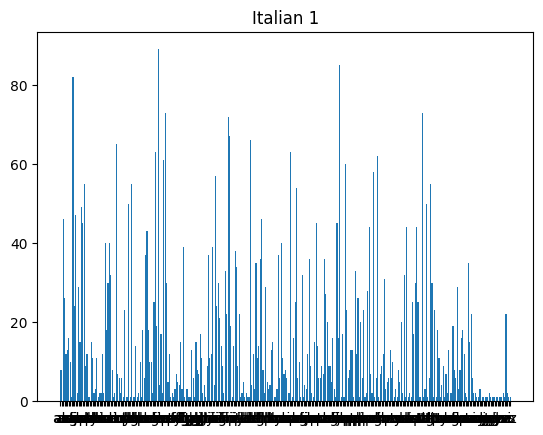

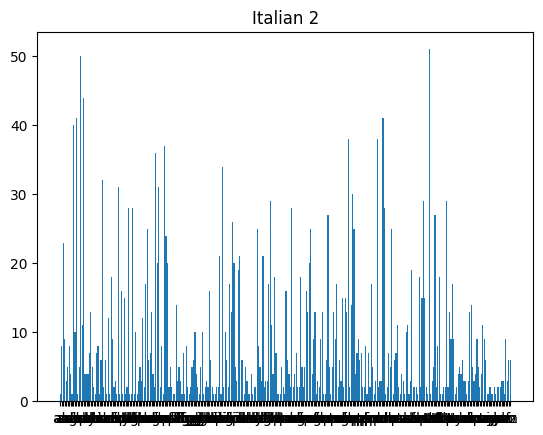

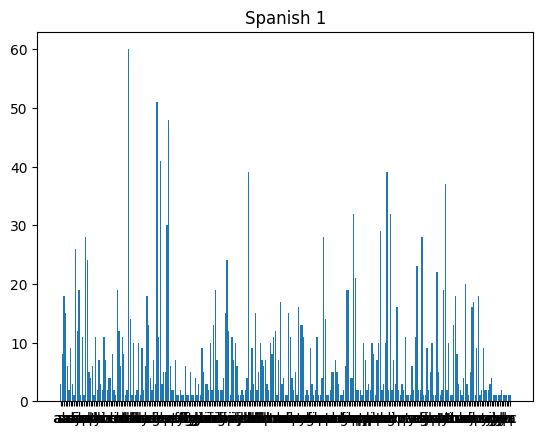

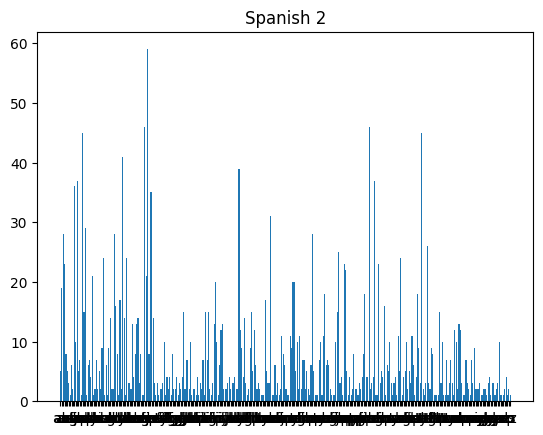

In [ ]:
bigram_it1 = Counter(ngrams(new_it1,2)) # bigrams
plothistogram(bigram_it1)
plt.title('Italian 1')
plt.show()

bigram_it2 = Counter(ngrams(new_it2,2))
plothistogram(bigram_it2)
plt.title('Italian 2')
plt.show()

bigram_es1 = Counter(ngrams(new_es1,2))
plothistogram(bigram_es1)
plt.title('Spanish 1')
plt.show()

bigram_es2 = Counter(ngrams(new_es2,2))
plothistogram(bigram_es2)
plt.title('Spanish 2')
plt.show()

In [ ]:
def plotbihistogram(ngram):
  freq = np.zeros((26,26))
  for ii in range(26):
    for jj in range(26):
      freq[ii,jj] = ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]
  plt.imshow(freq, cmap = 'jet')
  return freq

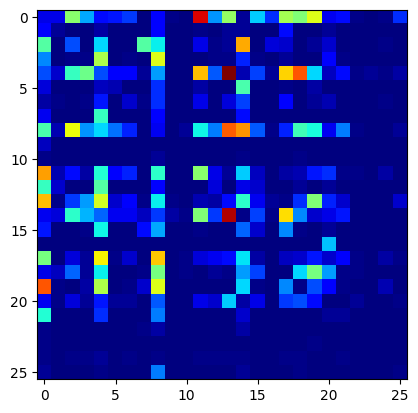

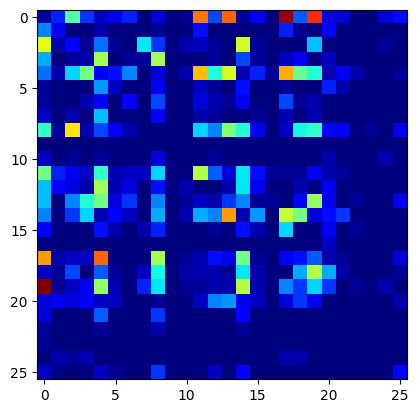

In [ ]:
bi_it1 = plotbihistogram(bigram_it1)
plt.show()
bi_it2 = plotbihistogram(bigram_it2)
plt.show()

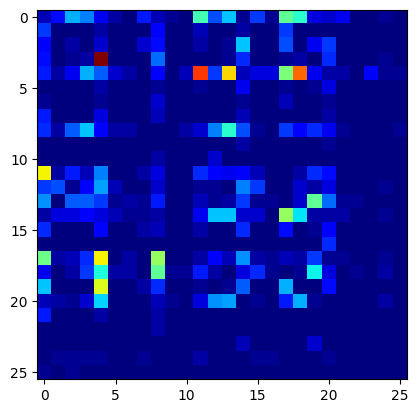

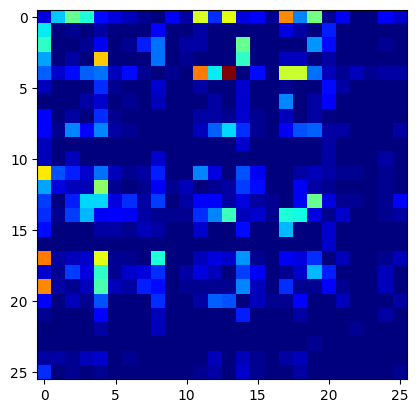

In [ ]:
bi_es1 = plotbihistogram(bigram_es1)
plt.show()
bi_es2 = plotbihistogram(bigram_es2)
plt.show()

In [ ]:
def ind2tup(ind):
  ind = int(ind)
  i = int(ind/26)
  j = int(ind%26)
  return (chr(ord('a')+i), chr(ord('a')+j))

def ShowTopN(bifreq, n=10):
  f = bifreq.flatten()
  arg = np.argsort(-f)
  for ii in range(n):
    print(f'{ind2tup(arg[ii])} : {f[arg[ii]]}')

In [ ]:
print('\nItalian 1:')
ShowTopN(bi_it1)
print('\nItalian 2:')
ShowTopN(bi_it2)
print('\nSpanish 1:')
ShowTopN(bi_es1)
print('\nSpanish 2:')
ShowTopN(bi_es2)


Italian 1:
('e', 'n') : 89.0
('o', 'n') : 85.0
('a', 'l') : 82.0
('e', 's') : 73.0
('t', 'a') : 73.0
('i', 'n') : 72.0
('i', 'o') : 67.0
('l', 'a') : 66.0
('c', 'o') : 65.0
('n', 'a') : 63.0

Italian 2:
('t', 'a') : 51.0
('a', 'r') : 50.0
('a', 't') : 44.0
('r', 'e') : 41.0
('a', 'n') : 41.0
('a', 'l') : 40.0
('r', 'a') : 38.0
('o', 'n') : 38.0
('e', 'r') : 37.0
('e', 'l') : 36.0

Spanish 1:
('d', 'e') : 60.0
('e', 'l') : 51.0
('e', 's') : 48.0
('e', 'n') : 41.0
('l', 'a') : 39.0
('r', 'e') : 39.0
('t', 'e') : 37.0
('o', 'r') : 32.0
('r', 'i') : 32.0
('e', 'r') : 30.0

Spanish 2:
('e', 'n') : 59.0
('e', 'l') : 46.0
('r', 'a') : 46.0
('t', 'a') : 45.0
('a', 'r') : 45.0
('d', 'e') : 41.0
('l', 'a') : 39.0
('r', 'e') : 37.0
('a', 'n') : 37.0
('a', 'l') : 36.0


We observe that bigram is not a good technique between italian and spanish, on googling just found out they are 82% - 85% lexically similar since they have a same latin root.

In [ ]:
top10_tfidf_it = tfidf_df_sorted.columns[:10].tolist()
top10_tfidf_es = tfidf_df_sorted_es.columns[:10].tolist()

print('Top 10 Italian TF-IDF words:', top10_tfidf_it)
print('Top 10 Spanish TF-IDF words:', top10_tfidf_es)

Top 5 Italian TF-IDF words: ['di', 'cataract', 'la', 'che', 'fu', 'il', 'nel', 'su', 'band', 'sinus']
Top 5 Spanish TF-IDF words: ['de', 'en', 'el', 'cataract', 'la', 'sinus', 'banda', 'cr', 'lbum', 'iridum']


In [ ]:
def get_top_n_bigrams(bifreq, n=200):
    f = bifreq.flatten()
    arg = np.argsort(-f)
    top_bigrams = []
    for ii in range(n):
        top_bigrams.append(ind2tup(arg[ii]))
    return top_bigrams

# Combine bigram frequencies for Italian documents
combined_bi_it = bi_it1 + bi_it2
# Combine bigram frequencies for Spanish documents
combined_bi_es = bi_es1 + bi_es2

topn_bigrams_it = get_top_n_bigrams(combined_bi_it)
topn_bigrams_es = get_top_n_bigrams(combined_bi_es)

print('Top n Italian Bigrams:', topn_bigrams_it)
print('Top n Spanish Bigrams:', topn_bigrams_es)

Top n Italian Bigrams: [('t', 'a'), ('o', 'n'), ('a', 'l'), ('e', 'n'), ('a', 't'), ('a', 'r'), ('e', 'l'), ('r', 'e'), ('e', 'r'), ('i', 'n'), ('e', 's'), ('c', 'o'), ('i', 'c'), ('l', 'a'), ('o', 'r'), ('r', 'i'), ('a', 'n'), ('i', 'o'), ('d', 'i'), ('r', 'a'), ('n', 'e'), ('n', 'a'), ('d', 'e'), ('t', 'e'), ('l', 'l'), ('t', 'i'), ('s', 't'), ('n', 't'), ('c', 'a'), ('a', 'c'), ('m', 'e'), ('e', 'd'), ('s', 'i'), ('i', 'a'), ('o', 'l'), ('t', 'o'), ('c', 'h'), ('i', 's'), ('a', 's'), ('r', 'o'), ('l', 'e'), ('i', 't'), ('e', 'c'), ('h', 'e'), ('l', 'i'), ('m', 'a'), ('e', 't'), ('i', 'l'), ('n', 'o'), ('o', 's'), ('l', 'o'), ('f', 'o'), ('o', 'c'), ('n', 'd'), ('s', 's'), ('n', 'i'), ('o', 'd'), ('s', 'e'), ('s', 'o'), ('u', 'n'), ('c', 'e'), ('c', 'i'), ('p', 'r'), ('p', 'e'), ('s', 'u'), ('i', 'e'), ('e', 'm'), ('v', 'a'), ('d', 'a'), ('t', 'r'), ('t', 't'), ('a', 'd'), ('i', 'm'), ('a', 'm'), ('p', 'i'), ('a', 'p'), ('o', 'p'), ('v', 'i'), ('z', 'i'), ('o', 'i'), ('q', 'u'), ('s'

In [ ]:
topn_bigrams_it_str = [''.join(bg) for bg in topn_bigrams_it]
topn_bigrams_es_str = [''.join(bg) for bg in topn_bigrams_es]

diff_it = set(top10_tfidf_it) - set(topn_bigrams_it_str)
diff_es = set(top10_tfidf_es) - set(topn_bigrams_es_str)

print('\nSet Difference (Italian TF-IDF vs Bigrams):', list(diff_it))
print('Set Difference (Spanish TF-IDF vs Bigrams):', list(diff_es))


Set Difference (Italian TF-IDF vs Bigrams): ['sinus', 'che', 'cataract', 'band', 'nel']
Set Difference (Spanish TF-IDF vs Bigrams): ['sinus', 'banda', 'lbum', 'cataract', 'iridum']


By find the sef difference between the top 10 words based on tfidf values and top 200 bigrams from the combined bigrams of both topics in each language we get the whole context of the topics.

Intitially, I thought the content for 'Cataract' would be of the eye disease, but the tfidf value for the word 'band'('banda' in spanish) is high for both Italian and Spanish, which is apparantly a famous Swiss metal band, and the spanish word 'lbum'(translates to 'album') also connects the context of the band.

Interestingly, the topic 'Sinus' had differnt contexts for both languages, I though the content would be about nasal disease, but ironically in the Italian Sinus article, it talks about Phocoena sinus (the vaquita) - A critically endangered porpoise species endemic exclusively to the northernmost Gulf of California, Mexico, while the word 'iridum' in spanish tells that the context for the same article is about the 'Sinus Iridum' - a plain of basaltic lava that forms a northwestern extension to the Mare Imbrium on the moon.

In [ ]:
! pip install googletrans==4.0.0-rc1

In [ ]:
from googletrans import Translator

def translate_words(words, dest_lang):
    translator = Translator()
    return {translator.translate(word, dest = dest_lang) for word in words}

it_to_eng = translate_words(diff_it, 'it')
es_to_eng = translate_words(diff_es, 'es')

common_words = it_to_eng.intersection(es_to_eng)
print(common_words)